<a href="https://colab.research.google.com/github/ablasve/Mini-Proyecto-Asistente-Multimodal-de-Salud/blob/main/FaseB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASE B: Procesamiento Multimodal de la información

En esta fase vamos a dedicarnos a lo central del proyecto: el procesamiento de la información de entrada (inputs) que puede tener formato de texto, imagen o audio, para después proporcionar una respuesta adecuada a las necesidades especificadas mediante modelos preentrenados de IA.

**Contenidos**<a id='toc0_'></a>   

[Librerías, modelos y funciones previas](#toc1)

[Grabadora de voz para Google Colab](#toc2)

[Opciones del asistente](#toc3)

- [Registrar medicamentos mediante imágenes](#toc3_1)

- [Modificar medicamentos](#toc3_3)

- [Tabla Resumen de los tratamientos](#toc3_3)

- [Preguntas por voz](#toc3_4)

- [Lector de documentos](#toc3_4)


<!-- vscode-jupyter-toc-config
    numbering=false
    anchor=true
    flat=false
    minLevel=1
    maxLevel=6
    /vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1'></a>[0. Librerías, modelos y funciones previas](#toc0_)

In [ ]:
# Para no tener problemas importando tantos modelos:
!pip install -q bitsandbytes
from transformers import BitsAndBytesConfig

# Para grabar AUDIO:
!pip install openai-whisper -q
import whisper
from google.colab import output
from base64 import b64decode

# Para reproducir AUDIO:
!pip install edge-tts -q
import edge_tts
import asyncio
from IPython.display import Audio, display

# Para administrar ARCHIVOS:
import json
import os
from google.colab import files
!apt-get install -y poppler-utils
!pip install pdf2image
from pdf2image import convert_from_path

# Para buscar EXPRESIONES REGULARES:
import re

# Para mostrar TABLAS bonitas EN HTML:
from IPython.display import display, HTML

# Para hacer gráficos:
import matplotlib.pyplot as plt
%matplotlib inline

# Para administrar IMÁGENES:
import PIL.Image

# Para pasar de VOZ a AUDIO:
from whisper import load_model
model_whisper = load_model("small") # Cargamos el modelo Whisper

# Para pasar de IMAGEN a TEXTO
!pip install -q transformers accelerate qwen-vl-utils

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
import torch
torch.cuda.empty_cache()

id_model = "Qwen/Qwen2-VL-2B-Instruct"

# Cargamos el procesador de imágenes
processor = AutoProcessor.from_pretrained(id_model)

# Configuración para ahorrar memoria (4 bits)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32
)

# Cargamos el modelo
model = Qwen2VLForConditionalGeneration.from_pretrained(
    id_model,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Modelo cargado con éxito")

from transformers import AutoModelForCausalLM, AutoTokenizer

# Cargamos el modelo de Texto puro para MIRAR SI LO VAMOS A USAR O NO!!!!!
#id_model_texto = "Qwen/Qwen2.5-1.5B-Instruct"
id_model_texto = "Qwen/Qwen2.5-3B-Instruct"

tokenizer_texto = AutoTokenizer.from_pretrained(id_model_texto)
model_texto = AutoModelForCausalLM.from_pretrained(
    id_model_texto,
    quantization_config=bnb_config,
    device_map="auto"
)
print("Modelo de TEXTO cargado con éxito")

#función auxiliar para tener la fecha en español
from datetime import datetime

def obtener_fecha_hoy_formato_json():
    # Diccionario con las abreviaturas exactas en español
    meses_abrev = [
        "ene", "feb", "mar", "abr", "may", "jun",
        "jul", "ago", "sep", "oct", "nov", "dic"
    ]

    hoy = datetime.now()

    # Formateamos el día para que siempre tenga 2 cifras (ej. 05 en vez de 5)
    dia = f"{hoy.day:02d}"
    mes = meses_abrev[hoy.month - 1]
    anio = hoy.year

    # Resultado final: ej. "26-mar-2026"
    return f"{dia}-{mes}-{anio}"


# Función para generar y reproducir el audio
async def generar_voz(texto):
    # Elegimos la voz: 'es-ES-ElviraNeural' (Mujer, España, muy clara)
    # O 'es-ES-AlvaroNeural' si prefieres hombre.
    VOICE = "es-ES-ElviraNeural"
    OUTPUT_FILE = "respuesta_asistente.mp3"

    communicate = edge_tts.Communicate(texto, VOICE, rate="-10%") # rate="-10%" si la quieres más lenta
    await communicate.save(OUTPUT_FILE)

    # Reproducir en Colab
    display(Audio(OUTPUT_FILE, autoplay=True))

# Forma de ejecutar la función:
# await generar_voz(respuesta_texto)

# Para cargar el HISTORIAL DEL USUARIO:
def cargar_memoria():
    if os.path.exists("memoria_salud.json"):
        with open("memoria_salud.json", "r") as f:
            return json.load(f)
    else:
        # Si no existe, creamos un perfil vacío
        return {"nombre": None, "medicinas": [], "ultimas_adiciones": []}

def guardar_memoria(datos):
    with open("memoria_salud.json", "w") as f:
        json.dump(datos, f, indent=4)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Modelo cargado con éxito


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo de TEXTO cargado con éxito


## <a id='toc2'></a>[1. Grabadora de voz para Google Colab](#toc0_)

Como Colab vive en la nube, no puede acceder directamente al micrófono con Python, por lo que necesitaremos definir una función puente, `grabar_audio`, con la que podremos recabar la información deseada a través del micrófono de los usuarios.

In [ ]:
# Código JavaScript para grabar audio desde el navegador
RECORD_JS = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  const recorder = new MediaRecorder(stream)
  const chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    const blob = new Blob(chunks)
    const text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

def grabar_audio(segundos=5):
    print(f"Escuchando durante {segundos} segundos...")
    output.eval_js(RECORD_JS)
    audio_b64 = output.eval_js(f"record({segundos*1000})")
    audio_bytes = b64decode(audio_b64.split(',')[1])
    with open("audio_usuario.wav", "wb") as f:
        f.write(audio_bytes)
    return "audio_usuario.wav"


## <a id='toc3'></a>[2. Opciones del asistente](#toc0_)

**DEBEMOS INICIALIZAR LA VARIABLE MEMORIA**

In [ ]:
memoria = cargar_memoria()

### <a id='toc3_1'></a>[2.1. Registrar medicamentos mediante imágenes](#toc0_)

En este primer apartado abordaremos la primera opción que ofrece el asistente: introducir los medicamentos mediante una foto de la receta o del envase. Para llevar a cabo esta tarea de forma local, sin depender de cuotas ni APIs externas, usaremos el modelo multimodal de código abierto Qwen2-VL. Este modelo de visión-lenguaje se ejecutará directamente sobre la GPU de nuestro entorno.

Primero desarrollaremos la función `analizar_receta`, que tiene como argumentos de entrada la ruta a la imagen y el histórico del usuario. Mediante un prompt específico pediremos al modelo que analice la imagen y proceda de la siguiente manera:

- Si detecta algún medicamento no presente en el historial, o alguno que ya estaba registrado pero cuyos campos hayan cambiado (por ejemplo, una nueva pauta para un medicamento habitual), unificará la información y nos devolverá un objeto JSON con dos elementos: una lista con todos los medicamentos y otra lista solo con las nuevas adiciones detectadas en la foto.
- Si no se detecta ningún tratamiento nuevo respecto al historial, devolverá simplemente _None_.

Para finalizar el proceso, la función `registrar_en_memoria` se encargará de actualizar y guardar los datos consolidados en la base de datos del usuario.

In [ ]:
# Fijamos los números mínimo y máximo de  píxeles para la foto
min_pixels = 256 * 28 * 28
# Aumentamos el máximo a casi 1 millón de píxeles para que lea el texto nítido
max_pixels = 1280 * 28 * 28


def analizar_receta(ruta_imagen, memoria):
  prompt = f"""
Extract prescription information from the image and return ONLY valid JSON.
The output must be in Spanish.

Format:
{{
  "lista_completa": [
    {{
      "nombre": "",
      "dosis": "",
      "fin": ""
    }}
  ],
  "adiciones": []
}}

Rules:
- Only JSON
- Escape all internal quotes
- All fields must be strings
- Keep Spanish text in output
- STRICTLY FORBIDDEN: Do not include info like legal texts, medical appointment reminders, prices, VAT/IVA, warnings about medicine accumulation, or prescription expiration info.
- "fin" = treatment end date

History (ignore for extraction):
{memoria.get('medicinas', [])}
"""

  mensajes = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": ruta_imagen},
                {"type": "text", "text": prompt},
            ],
        }
    ]

  try:
      print("El modelo local está leyendo la imagen...")

      text = processor.apply_chat_template(mensajes, tokenize=False, add_generation_prompt=True)
      image_inputs, video_inputs = process_vision_info(mensajes)

      inputs = processor(
          text=[text],
          images=image_inputs,
          videos=video_inputs,
          padding=True,
          return_tensors="pt",
          min_pixels=min_pixels,
          max_pixels=max_pixels
      ).to("cuda")

      with torch.no_grad():
          generated_ids = model.generate(**inputs, max_new_tokens=1024)

      generated_ids_trimmed = [
          out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
      ]

      del inputs
      del generated_ids
      torch.cuda.empty_cache()

      texto_respuesta = processor.batch_decode(
          generated_ids_trimmed,
          skip_special_tokens=True
      )[0].strip()

      # Extraer JSON
      match = re.search(r'\{.*\}', texto_respuesta, re.DOTALL)
      if not match:
          print("No hay JSON válido en la respuesta")
          print(texto_respuesta)
          return None

      json_text = match.group(0)

      # Escapar comillas internas
      json_text = re.sub(r'(\w)"(\w)', r'\1\\"\\2', json_text)

      datos_json = json.loads(json_text)

      lista = datos_json.get("lista_completa", [])
      adiciones = datos_json.get("adiciones", [])

      if not lista:
          return None

      return [lista, adiciones]

  except Exception as e:
      print("Error:", e)
      return None

In [ ]:
def registrar_en_memoria(nuevos_datos):
    memoria = cargar_memoria()
    memoria.setdefault('medicinas', [])
    memoria.setdefault('ultimas_adiciones', [])

    lista_nuevas = nuevos_datos[0]  # recetas extraídas
    ultimas_adiciones = []

    for receta in lista_nuevas:
        # Identificador único: nombre + dosis + fecha fin
        key = (receta['nombre'], receta['dosis'], receta['fin'])
        # comprobar si ya existe
        existe = any(
            (m['nombre'], m['dosis'], m['fin']) == key
            for m in memoria['medicinas']
        )
        if not existe:
            memoria['medicinas'].append(receta)
            ultimas_adiciones.append(receta)

    memoria['ultimas_adiciones'] = ultimas_adiciones

    guardar_memoria(memoria)
    return memoria

Probamos las funciones con las recetas de ejemplo `Recetas_Fulanita1.jpeg` y `Recetas_Fulanita.jpeg`.



In [ ]:
# primero inspeccionamos memoria (debería estar vacía)
memoria = cargar_memoria()

# visualizamos las medicinas y cuáles se han introducido las últimas
print("Historial:", memoria.get('medicinas', []))
print("Últimas:", memoria.get('ultimas_adiciones', []))

# ==========================================
# PRUEBA RECETA 1
# ==========================================
print("\n--- Analizando Receta 1 ---")
medicacion1 = analizar_receta("Recetas_Fulanita1.jpeg", memoria)

# Comprobamos que todo ha ido bien y se han registrado nuevos medicamentos
if medicacion1 is not None:
    memoria = registrar_en_memoria(medicacion1)
    print("Receta 1 guardada con éxito")
else:
    print("No se ha guardado la receta 1 porque la IA no encontró datos válidos o devolvió un error.")

# visualizamos la base de datos actualizada
print("Historial:", memoria.get('medicinas', []))
print("Últimas:", memoria.get('ultimas_adiciones', []))

# ==========================================
# PRUEBA RECETA 2
# ==========================================
print("\n--- Analizando Receta 2 ---")
medicacion2 = analizar_receta("Recetas_Fulanita.jpeg", memoria)

# Comprobamos que todo ha ido bien y se han registrado nuevos medicamentos
if medicacion2 is not None:
    memoria = registrar_en_memoria(medicacion2)
    print("Receta 2 guardada con éxito")
else:
    print("No se ha guardado la receta 2 porque la IA no encontró datos nuevos o devolvió un error.")

# visualizamos la base de datos actualizada
print("Historial:", memoria.get('medicinas', []))
print("Últimas:", memoria.get('ultimas_adiciones', []))

Historial: [{'nombre': 'AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]', 'dosis': '1 COMPRIMIDO cada 8 horas durante 7 días', 'fin': '26-mar-2026'}, {'nombre': 'FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA]', 'dosis': '1 COMPRIMIDO EFERVESCENTE cada día durante 7 días', 'fin': '26-mar-2026'}, {'nombre': 'PARACETAMOL 1000 MG / 40 COMPRIMIDOS', 'dosis': '1 COMPRIMIDO cada 8 horas durante 7 días', 'fin': '26-mar-2026'}, {'nombre': 'XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA]', 'dosis': '1 COMPRIMIDO cada día durante 7 días', 'fin': '26-mar-2026'}, {'nombre': 'OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN]', 'dosis': '1 COMPRIMIDO cada día durante 30 días', 'fin': '26-mar-2026'}, {'nombre': 'CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES', 'dosis': '1 COMPRIMIDO cada dia CRÓNICO', 'fin': '01-oct-2026'}]
Últimas: [{'nombre': 'AUGMENTINE 500/125MG 

In [ ]:
# visualizamos la base de datos actualizada, para ver si no ha duplicado la info
for dic in memoria['medicinas']:
    print(f'--- {dic.get("nombre", "")} ---')
    print(f'Dosis: {dic.get("dosis", "")}')
    print(f'Fecha de fin: {dic.get("fin", "")}\n')

print('Últimas medicinas añadidas:')
for med in memoria['ultimas_adiciones']:
  print(f'- {med}')
if not memoria['ultimas_adiciones']:
  print('No hay medicinas añadidas recientemente')

--- AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] ---
Dosis: 1 COMPRIMIDO cada 8 horas durante 7 días
Fecha de fin: 26-mar-2026

--- FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] ---
Dosis: 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días
Fecha de fin: 26-mar-2026

--- PARACETAMOL 1000 MG / 40 COMPRIMIDOS ---
Dosis: 1 COMPRIMIDO cada 8 horas durante 7 días
Fecha de fin: 26-mar-2026

--- XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] ---
Dosis: 1 COMPRIMIDO cada día durante 7 días
Fecha de fin: 26-mar-2026

--- OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] ---
Dosis: 1 COMPRIMIDO cada día durante 30 días
Fecha de fin: 26-mar-2026

--- CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES ---
Dosis: 1 COMPRIMIDO cada dia CRÓNICO
Fecha de fin: 01-oct-2026

Últimas medicinas añadidas:
- {'nombre': 'FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [AC

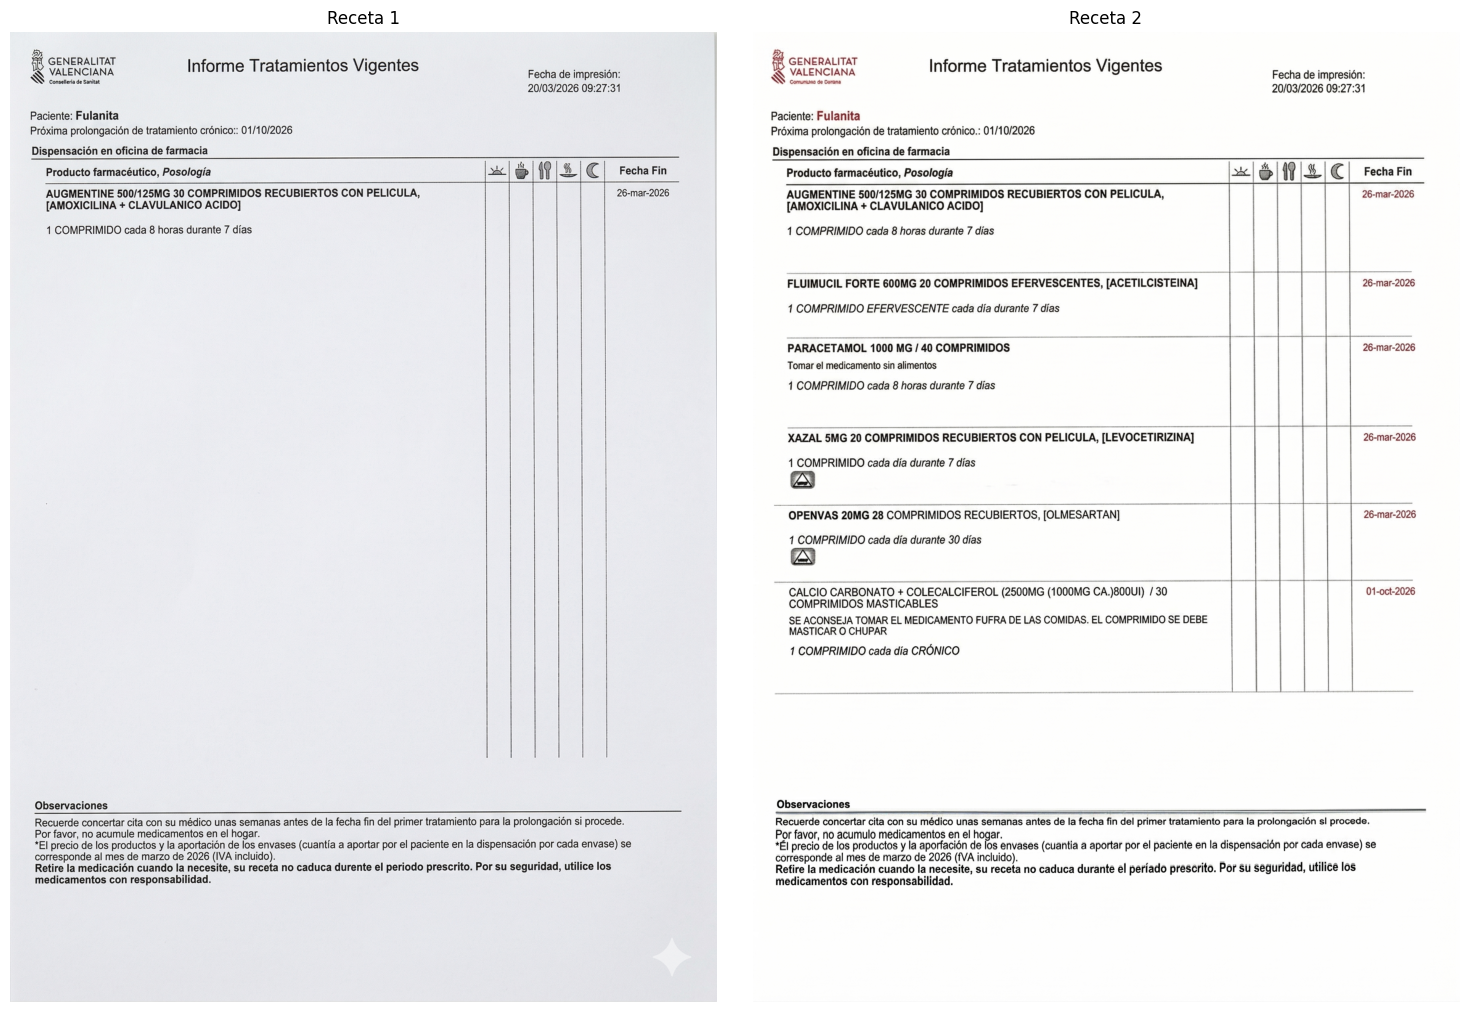

In [ ]:
# Cargar las imágenes desde la ruta local de Colab
img1 = PIL.Image.open('/content/Recetas_Fulanita1.jpeg')
img2 = PIL.Image.open('/content/Recetas_Fulanita.jpeg')

# mostrarlas juntas
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

axes[0].imshow(img1)
axes[0].set_title("Receta 1")
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title("Receta 2")
axes[1].axis('off')

fig.tight_layout()



Vemos que lo ha hecho perfectamente, ya que la primera receta que le hemos proporcionado era la misma que la segunda, a excepción de la cantidad de medicamentos que hemos dejado visibles. Aunque el primer medicamento estuviese repetido, al procesar la segunda receta el modelo ha sido capaz de identificarlo y en el archivo de memoria final solo hemos obtenido la información deseada, sin rastro de duplicados.

Programemos y veamos si funciona correctamente la función para ejecutar la opción 1, a la cual le volveremos a pasar la segunda receta. La función `ejecutar_opcion_1` pide al usuario que suba la imagen, usa `analizar_receta` para procesar la información y, dependiendo del resultado que proporcione, o bien informa de que ha actualizado el historial, o bien informa de que no había necesidad de hacerlo y lo muestra para que el usuario pueda comprobar que todos los medicamentos están registrados.

In [ ]:
async def ejecutar_opcion_1(memoria):
    print("\n[Asistente]: Por favor, sube la foto de tu receta o medicina.")
    await generar_voz("Por favor, sube la foto de tu receta o medicina.")

    # esperamos a que acabe el audio para subir el archivo
    await asyncio.sleep(5)

    # Abre el selector de archivos de Colab
    subido = files.upload()

    await asyncio.sleep(5)

    if subido:
        nombre_archivo = list(subido.keys())[0]

        print("--- Analizando imagen... ---")
        datos_extraidos = analizar_receta(nombre_archivo, memoria)

        if datos_extraidos:
            # Guardamos en la memoria JSON
            memoria_actualizada = registrar_en_memoria(datos_extraidos)

            # Extraemos las últimas adiciones que sí se guardaron
            ultimas = memoria_actualizada.get('ultimas_adiciones', [])

            if ultimas:
                nombres = [med['nombre'] for med in ultimas]
                if len(nombres) == 1:
                    confirmacion = f"He leído y guardado correctamente: {nombres[0]}. Ya está en tu lista de recordatorios."
                else:
                    confirmacion = f"He leído y guardado correctamente: {', '.join(nombres[:-1])} y {nombres[-1]}. Ya están en tu lista de recordatorios."
            else:
                confirmacion = "No se han añadido nuevas medicinas; ya estaban en tu lista."

            print(f"\n[Asistente]: {confirmacion}")
            await generar_voz(confirmacion)

            # Mostramos cómo queda la lista visualmente
            mostrar_recordatorios(memoria_actualizada)

            # Borramos el archivo tras procesarlo
            if os.path.exists(nombre_archivo):
                os.remove(nombre_archivo)
                print(f"Archivo temporal '{nombre_archivo}' eliminado.")

            return memoria_actualizada

        else:
            confirmacion = f"""
            He leído la información que me has proporcionado, y ya estaba introducida en el registro.
            Aquí tienes el registro y puedes comprobar que está todo en orden:
            """

            print(f"\n[Asistente]: {confirmacion}")
            await generar_voz(confirmacion)

            # Mostramos cómo queda la lista visualmente
            mostrar_recordatorios(memoria)

            # Borramos el archivo tras procesarlo
            if os.path.exists(nombre_archivo):
                os.remove(nombre_archivo)
                print(f"Archivo temporal '{nombre_archivo}' eliminado.")

            return memoria

    await generar_voz("No se ha subido ninguna imagen.")
    return memoria

def mostrar_recordatorios(memoria):
    print("\n--- TUS MEDICAMENTOS REGISTRADOS ---")
    for m in memoria["medicinas"]:
        fin = m.get('fin', '')
        print(f"💊 {m['nombre']} - {m['dosis']} - Fecha Fin Tratamiento: {fin}")
    print("------------------------------------\n")



Probemos primero a subir la última receta que ya habíamos introducido en la memoria; `Recetas_Fulanita.jpeg`.

In [ ]:
memoria = await ejecutar_opcion_1(memoria)


[Asistente]: Por favor, sube la foto de tu receta o medicina.


Saving Recetas_Fulanita.jpeg to Recetas_Fulanita (1).jpeg
--- Analizando imagen... ---
El modelo local está leyendo la imagen...

[Asistente]: He leído y guardado correctamente: AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO], FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA], PARACETAMOL 1000 MG / 40 COMPRIMIDOS, XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA], OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] y CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES. Ya están en tu lista de recordatorios.



--- TUS MEDICAMENTOS REGISTRADOS ---
💊 AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] - 1 COMPRIMIDO cada 8 horas durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] - 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 PARACETAMOL 1000 MG / 40 COMPRIMIDOS - 1 COMPRIMIDO cada 8 horas durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] - 1 COMPRIMIDO cada día durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] - 1 COMPRIMIDO cada día durante 30 días - Fecha Fin Tratamiento: 26-mar-2026
💊 CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES - 1 COMPRIMIDO cada dia CRÓNICO - Fecha Fin Tratamiento: 01-oct-2026
------------------------------------

Archivo temporal 'Recetas_F

Como queríamos, ha detectado que toda la información estaba ya subida, por lo que no ha cambiado nada y simplemente nos informado de la lista completa de medicinas que tiene registradas. Probemos ahora volviendo a inicializar la memoria, si al pasarle `Recetas_Fulanita.jpeg` se guardan correctamente todos los medicamentos.

In [ ]:
# borramos memoria
memoria = cargar_memoria()
memoria = {"nombre": None, "medicinas": [], "ultimas_adiciones": []}
guardar_memoria(memoria)

# introducimos todos los medicamentos con la 1a opción
memoria = await ejecutar_opcion_1(memoria)


[Asistente]: Por favor, sube la foto de tu receta o medicina.


Saving Recetas_Fulanita.jpeg to Recetas_Fulanita.jpeg
--- Analizando imagen... ---
El modelo local está leyendo la imagen...

[Asistente]: He leído y guardado correctamente: AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO], FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA], PARACETAMOL 1000 MG / 40 COMPRIMIDOS, XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA], OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] y CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES. Ya están en tu lista de recordatorios.



--- TUS MEDICAMENTOS REGISTRADOS ---
💊 AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] - 1 COMPRIMIDO cada 8 horas durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] - 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 PARACETAMOL 1000 MG / 40 COMPRIMIDOS - 1 COMPRIMIDO cada 8 horas durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] - 1 COMPRIMIDO cada día durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] - 1 COMPRIMIDO cada día durante 30 días - Fecha Fin Tratamiento: 26-mar-2026
💊 CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES - 1 COMPRIMIDO cada dia CRÓNICO - Fecha Fin Tratamiento: 01-oct-2026
------------------------------------

Archivo temporal 'Recetas_F

In [ ]:
print(memoria)

Efectivamente, la función ha sido capaz, aunque vemos que tiene ciertos problemas a la hora de pronunciar abreviaciones ("MG") o interpretar signos ("/").

### <a id='toc3_3'></a>[2.2. Modificación de Medicamentos](#toc0_)

La siguiente opción que ofrece la aplicación permite al usuario modificar su historial de medicación. Se puede cambiar el nombre, la dosis o la fecha de finalización de los medicamentos ya registrados, o eliminarlos si se desea. En caso de querer añadir un nuevo medicamento, esta acción se redirige a la opción de subir una nueva receta.


In [ ]:
# ================================
# MENÚ PRINCIPAL
# ================================
async def ejecutar_opcion_2_menu(memoria):
    historial = memoria.get("medicinas", [])

    if not historial:
        await generar_voz("No hay medicamentos registrados aún.")
        return memoria

    # Mostrar menú al usuario
    menu_texto = (
        "Diga el número de la opción que le interesa:\n"
        "1. Eliminar un medicamento\n"
        "2. Modificar un medicamento\n"
    )
    print(f"\n[Asistente]: {menu_texto}")
    await generar_voz(menu_texto)

    # Esperar unos segundos para que se reproduzca completamente
    await asyncio.sleep(9)

    # Escuchar respuesta
    archivo_audio = grabar_audio(segundos=5)
    resultado = model_whisper.transcribe(archivo_audio, language="es")
    eleccion_texto = resultado["text"].strip().lower()
    print(f"Has elegido: {eleccion_texto}")

    # Convertir respuesta a número de opción
    prompt_normalizar = f"""
    El usuario ha dicho: "{eleccion_texto}"

    Devuelve solo un número (1 o 2) que corresponde a la opción correcta:
    1 → Eliminar un medicamento
    2 → Modificar un medicamento

    Responde solo con el número, nada más.
    """

    # Preparar input para Qwen de texto
    messages = [
        {"role": "system", "content": "Eres un asistente que convierte texto en un número de opción."},
        {"role": "user", "content": prompt_normalizar}
    ]

    text_input = tokenizer_texto.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer_texto(text_input, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model_texto.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False, # el modelo siempre toma el token más probable (como “greedy decoding”)
            temperature=None,
            top_p=None,
            top_k=None

        )

    # Extraer número
    respuesta_completa = tokenizer_texto.decode(outputs[0], skip_special_tokens=True).strip()
    # Buscar el contenido después de la última aparición de 'assistant'
    match = re.search(r'assistant\s*(.*)', respuesta_completa, re.IGNORECASE | re.DOTALL)
    if match:
        respuesta_modelo = match.group(1).strip()  # Esto es solo lo que generó el modelo
    else:
        respuesta_modelo = respuesta_completa  # fallback

    # Ahora extraemos solo el dígito
    match_num = re.search(r'\b([12])\b', respuesta_modelo)
    if match_num:
        numero_opcion = int(match_num.group(1))
    else:
        await generar_voz("No entendí tu elección. Vamos a intentarlo de nuevo.")
        # esperamos a que diga la frase para empezar de nuevo
        await asyncio.sleep(4)
        return await ejecutar_opcion_2_menu(memoria)

    # Convertir a int y manejar error
    try:
        opcion = int(numero_opcion)
    except:
        await generar_voz("No entendí tu elección. Vamos a intentarlo de nuevo.")
        # esperamos a que diga la frase para empezar de nuevo
        await asyncio.sleep(4)
        return await ejecutar_opcion_2_menu(memoria)

    # Ejecutar flujo correspondiente
    if opcion == 1:
        memoria = await ejecutar_opcion_2_eliminar(memoria)
    elif opcion == 2:
        memoria = await ejecutar_opcion_2_modificar(memoria)

    return memoria

# ================================
# ELIMINAR MEDICAMENTO
# ================================
async def ejecutar_opcion_2_eliminar(memoria):
    historial = memoria.get("medicinas", [])

    if not historial:
        await generar_voz("No hay medicamentos para eliminar.")
        return memoria

    # Mostrar lista de medicamentos
    print("\n--- Lista actual de medicamentos ---")
    for i, med in enumerate(historial, 1):
        print(f"{i}. {med['nombre']} - {med['dosis']} - Fin: {med['fin']}")
    print("-----------------------------------")
    await generar_voz("Estos son tus medicamentos actuales.")

    # Esperar unos segundos para que se reproduzca completamente
    await asyncio.sleep(4)

    # Pedir nombre del medicamento a eliminar
    mensaje = "Dime el número del medicamento que quieres eliminar."
    print(f"\n[Asistente]: {mensaje}")
    await generar_voz(mensaje)
    await asyncio.sleep(5)

    archivo_audio = grabar_audio(segundos=8)
    resultado = model_whisper.transcribe(archivo_audio, language="es")
    eleccion_texto = resultado["text"].strip().lower()
    print(f"Has dicho: {eleccion_texto}")

    # Buscar coincidencias
    prompt_normalizar = f"""
    El usuario ha dicho: "{eleccion_texto}"

    Devuelve solo el número del medicamento que quiere seleccionar.

    Reglas:
    - Si el número está escrito en letras pásalo a formato NÚMERO
    - Responde SOLO con un número
    - No escribas nada más
    """

    messages = [
        {"role": "system", "content": "Eres un asistente que convierte texto en un número."},
        {"role": "user", "content": prompt_normalizar}
    ]

    text_input = tokenizer_texto.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer_texto(text_input, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model_texto.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False
        )

    respuesta_completa = tokenizer_texto.decode(outputs[0], skip_special_tokens=True).strip()

    match = re.search(r'assistant\s*(.*)', respuesta_completa, re.IGNORECASE | re.DOTALL)

    if match:
        respuesta_modelo = match.group(1).strip()
    else:
        respuesta_modelo = respuesta_completa

    match_num = re.search(r'\b(\d+)\b', respuesta_modelo)
    if match_num:
        indice = int(match_num.group(1))-1
    else:
        await generar_voz("No entendí el número. Vamos a intentarlo de nuevo.")
        return await ejecutar_opcion_2_eliminar(memoria)

    if 0 <= indice < len(historial):
        med = historial[indice]

        confirm_msg = f"¿Seguro que quieres eliminar {med['nombre']}?"
        print(confirm_msg)
        await generar_voz(confirm_msg)
        await asyncio.sleep(10)

        archivo_conf = grabar_audio(segundos=5)
        resultado_conf = model_whisper.transcribe(archivo_conf, language="es")
        respuesta_conf = resultado_conf["text"].lower()

        if any(p in respuesta_conf for p in ["sí", "si", "vale", "correcto"]):
            memoria["medicinas"].pop(indice)
            guardar_memoria(memoria)
            await generar_voz(f"He eliminado {med['nombre']}.")
            await asyncio.sleep(11)
            await generar_voz(f"Aquí tienes tu lista actualizada.")
            mostrar_recordatorios(memoria)

        else:
            await generar_voz("No he eliminado el medicamento.")
            await asyncio.sleep(3)
        return memoria
    else:
        await generar_voz("Ese número no está en la lista. Vamos a probar de nuevo.")
        await asyncio.sleep(5)
        return await ejecutar_opcion_2_eliminar(memoria)


# ================================
# MODIFICAR MEDICAMENTO
# ================================
async def ejecutar_opcion_2_modificar(memoria):
    historial = memoria.get("medicinas", [])

    if not historial:
        await generar_voz("No hay medicamentos para modificar.")
        await asyncio.sleep(4)
        return memoria

    # Mostrar lista actual
    print("\n--- Lista actual de medicamentos ---")
    for i, med in enumerate(historial, 1):
        print(f"{i}. {med['nombre']} - {med['dosis']} - Fin: {med['fin']}")
    print("-----------------------------------")
    await generar_voz("Estos son tus medicamentos actuales.")

    # Esperar unos segundos para que se reproduzca completamente
    await asyncio.sleep(5)

    # Pedir nombre del medicamento a eliminar
    mensaje = "Dime el número del medicamento que quieres modificar."
    print(f"\n[Asistente]: {mensaje}")
    await generar_voz(mensaje)
    await asyncio.sleep(5)

    archivo_audio = grabar_audio(segundos=8)
    resultado = model_whisper.transcribe(archivo_audio, language="es")
    eleccion_texto = resultado["text"].strip().lower()
    print(f"Has dicho: {eleccion_texto}")

    # Buscar coincidencias
    prompt_normalizar = f"""
    El usuario ha dicho: "{eleccion_texto}"

    Devuelve solo el número del medicamento que quiere seleccionar.

    Reglas:
    - Si el número está escrito en letras pásalo a formato NÚMERO
    - Responde SOLO con un número
    - No escribas nada más
    """

    messages = [
        {"role": "system", "content": "Eres un asistente que convierte texto en un número."},
        {"role": "user", "content": prompt_normalizar}
    ]

    text_input = tokenizer_texto.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer_texto(text_input, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model_texto.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            temperature=None,
            top_p=None,
            top_k=None

        )

    respuesta_completa = tokenizer_texto.decode(outputs[0], skip_special_tokens=True).strip()

    match = re.search(r'assistant\s*(.*)', respuesta_completa, re.IGNORECASE | re.DOTALL)

    if match:
        respuesta_modelo = match.group(1).strip()
    else:
        respuesta_modelo = respuesta_completa

    match_num = re.search(r'\b(\d+)\b', respuesta_modelo)
    if match_num:
        indice = int(match_num.group(1))-1
    else:
        await generar_voz("No entendí el número. Vamos a intentarlo de nuevo.")
        await asyncio.sleep(5)
        return await ejecutar_opcion_2_modificar(memoria)

    if not (0 <= indice < len(historial)):
      await generar_voz("Ese número no está en la lista. Vamos a intentarlo de nuevo.")
      await asyncio.sleep(5)
      return await ejecutar_opcion_2_modificar(memoria)

    med = historial[indice]

    # ========================
    # QUÉ MODIFICAR
    # ========================
    mensaje = f"Vas a modificar {med['nombre']}. ¿Qué campo quieres cambiar: nombre, dosis o fecha fin?"

    print(f"\n[Asistente]: {mensaje}")
    await generar_voz(mensaje)
    await asyncio.sleep(12)
    archivo_audio = grabar_audio(segundos=7)
    resultado = model_whisper.transcribe(archivo_audio, language="es")
    campo_texto = resultado["text"].lower()
    print(f"Campo: {campo_texto}")

    # IA para interpretar campo
    prompt_campo = f"""
    El usuario ha dicho: "{campo_texto}"
    Devuelve SOLO una de estas palabras: nombre, dosis o fin.
    """

    messages = [
        {"role": "system", "content": "Clasifica en nombre, dosis o fin."},
        {"role": "user", "content": prompt_campo}
    ]

    text_input = tokenizer_texto.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer_texto(text_input, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model_texto.generate(**inputs, max_new_tokens=5, do_sample=False)

    respuesta = tokenizer_texto.decode(outputs[0], skip_special_tokens=True)
    match = re.search(r'assistant\s*(.*)', respuesta, re.DOTALL)
    campo = match.group(1).strip() if match else respuesta.strip()

    if campo not in ["nombre", "dosis", "fin"]:
        await generar_voz("No entendí qué quieres modificar. Vamos a intentarlo de nuevo.")
        await asyncio.sleep(4)
        return await ejecutar_opcion_2_modificar(memoria)

    # ========================
    # NUEVO VALOR
    # ========================
    await generar_voz(f"Dime el nuevo valor para {campo}.")
    await asyncio.sleep(5)

    archivo_audio = grabar_audio(segundos=10)
    resultado = model_whisper.transcribe(archivo_audio, language="es")
    nuevo_valor = resultado["text"].strip()

    print(f"Nuevo valor: {nuevo_valor}")

    # ========================
    # CONFIRMACIÓN
    # ========================
    await generar_voz(f"¿Confirmas cambiar {campo} a {nuevo_valor}? (Responde con SÍ o NO)")
    await asyncio.sleep(10)

    archivo_audio = grabar_audio(segundos=5)
    resultado = model_whisper.transcribe(archivo_audio, language="es")
    confirmacion = resultado["text"].lower()

    if any(p in confirmacion for p in ["sí", "si", "vale", "correcto"]):
        valor_anterior = med[campo]

        med[campo] = nuevo_valor
        guardar_memoria(memoria)

        # Mostrar cambio en consola
        print("\n--- Cambio realizado ---")
        print(f"Medicamento: {med['nombre']}")
        print(f"{campo.upper()}:")
        print(f"  Antes: {valor_anterior}")
        print(f"  Ahora: {nuevo_valor}")
        print("------------------------")

        await generar_voz(f"He actualizado {campo} de {valor_anterior} a {nuevo_valor}.")

        # Mostrar lista completa actualizada
        mostrar_recordatorios(memoria)

    else:
        await generar_voz("No se ha realizado ningún cambio.")

    return memoria


In [ ]:
memoria = await ejecutar_opcion_2_menu(memoria)


[Asistente]: Diga el número de la opción que le interesa:
1. Eliminar un medicamento
2. Modificar un medicamento



Escuchando durante 5 segundos...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Has elegido: uno

--- Lista actual de medicamentos ---
1. AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] - 1 COMPRIMIDO cada 8 horas durante 7 días - Fin: 26-mar-2026
2. FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] - 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días - Fin: 26-mar-2026
3. PARACETAMOL 1000 MG / 40 COMPRIMIDOS - 1 COMPRIMIDO cada 8 horas durante 7 días - Fin: 26-mar-2026
4. XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] - 1 COMPRIMIDO cada día durante 7 días - Fin: 26-mar-2026
5. OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] - 1 COMPRIMIDO cada día durante 30 días - Fin: 26-mar-2026
6. CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES - 1 COMPRIMIDO cada dia CRÓNICO - Fin: 01-oct-2026
-----------------------------------



[Asistente]: Dime el número del medicamento que quieres eliminar.


Escuchando durante 8 segundos...
Has dicho: σας. uno porque hay
¿Seguro que quieres eliminar AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]?


Escuchando durante 5 segundos...


In [ ]:
print(memoria)

En la celda anterior le hemos pedido al asistente que eliminase el calcio de la lista de medicinas, y vemos que ha entendido todas las respuestas a la primera, ha borrado el calcio y ha cambiado el archivo _JSON_. En la siguiente celda le pediremos que modifique el paracetamol, poniendo como dosis un comprimido cada doce horas durante 3 días.

In [ ]:
memoria = await ejecutar_opcion_2_menu(memoria)


[Asistente]: Diga el número de la opción que le interesa:
1. Eliminar un medicamento
2. Modificar un medicamento



Escuchando durante 5 segundos...


None

Has elegido: dos

--- Lista actual de medicamentos ---
1. AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] - 1 COMPRIMIDO cada 8 horas durante 7 días - Fin: 26-mar-2026
2. FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] - 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días - Fin: 26-mar-2026
3. PARACETAMOL 1000 MG / 40 COMPRIMIDOS - 1 COMPRIMIDO cada 8 horas durante 7 días - Fin: 26-mar-2026
4. XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] - 1 COMPRIMIDO cada día durante 7 días - Fin: 26-mar-2026
5. OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] - 1 COMPRIMIDO cada día durante 30 días - Fin: 26-mar-2026
-----------------------------------



[Asistente]: Dime el número del medicamento que quieres modificar.


...

Nuevo valor: Un comprimido cada 12 horas durante 3 días.


Escuchando durante 5 segundos...


None


--- Cambio realizado ---
Medicamento: PARACETAMOL 1000 MG / 40 COMPRIMIDOS
DOSIS:
  Antes: 1 COMPRIMIDO cada 8 horas durante 7 días
  Ahora: Un comprimido cada 12 horas durante 3 días.
------------------------



--- TUS MEDICAMENTOS REGISTRADOS ---
💊 AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] - 1 COMPRIMIDO cada 8 horas durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] - 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 PARACETAMOL 1000 MG / 40 COMPRIMIDOS - Un comprimido cada 12 horas durante 3 días. - Fecha Fin Tratamiento: 26-mar-2026
💊 XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] - 1 COMPRIMIDO cada día durante 7 días - Fecha Fin Tratamiento: 26-mar-2026
💊 OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] - 1 COMPRIMIDO cada día durante 30 días - Fecha Fin Tratamiento: 26-mar-2026
------------------------------------



In [ ]:
print(memoria)

### <a id='toc3_3'></a>[2.3. Resumen de los tratamientos activos](#toc0_)

La siguiente opción que ofrece la aplicación es generar un breve resumen con las indicaciones de qué medicamentos y con qué posología ha de tomar el usuario el día de la consulta según la información recogida en el historial. El resultado será una tabla con las medicaciones de ese día.

In [ ]:
def ejecutar_opcion_3(datos_medicinas):
    print("Organizando horarios con lógica exacta...")

    if isinstance(datos_medicinas, dict):
        datos_medicinas = datos_medicinas.get("medicinas", [])

    horarios = {"Mañana": [], "Mediodía": [], "Noche": []}

    hoy = datetime.now().date()

    for med in datos_medicinas:
        nombre = med.get("nombre", "").strip()
        dosis = med.get("dosis", "").strip()
        fin = med.get("fin", "").strip()

        # ---- FILTRAR POR FECHA ----
        if fin:
            try:
                fecha_fin = datetime.strptime(fin, "%d-%m-%Y").date()
                if fecha_fin < hoy:
                    continue
            except:
                pass

        # ---- LIMPIAR DOSIS ----
        dosis_limpia = re.split(r'\b(cada|durante)\b', dosis, flags=re.IGNORECASE)[0].strip(" ,.-")

        item = f"{nombre}<br><span style='color:red; font-weight:bold;'>{dosis_limpia}</span>"
        dosis_lower = dosis.lower()

        # ---- DISTRIBUCIÓN ----
        if "8 horas" in dosis_lower or "3 veces" in dosis_lower:
            horarios["Mañana"].append(item)
            horarios["Mediodía"].append(item)
            horarios["Noche"].append(item)

        elif "12 horas" in dosis_lower or "2 veces" in dosis_lower:
            horarios["Mañana"].append(item)
            horarios["Noche"].append(item)

        elif "24 horas" in dosis_lower or "1 vez" in dosis_lower or "cada día" in dosis_lower:
            horarios["Mañana"].append(item)

        else:
            horarios["Mañana"].append(item)

    def formatear(lista):
        if not lista:
            return "<i>Nada</i>"
        return "<br><br>".join(lista)

    html = f"""
    <div style="font-family: Arial; max-width: 650px; margin: 20px auto; border: 2px solid #333; border-radius: 15px; overflow: hidden;">
        <h2 style="background:#4CAF50;color:white;text-align:center;padding:15px;margin:0;">
            📅 Tu medicación diaria
        </h2>

        <table style="width:100%; border-collapse: collapse; font-size:18px;">
            <tr style="background:#FFF9C4;">
                <td style="padding:15px;font-weight:bold;width:30%;">☀️ Mañana</td>
                <td style="padding:15px;">{formatear(horarios["Mañana"])}</td>
            </tr>
            <tr style="background:#FFE0B2;">
                <td style="padding:15px;font-weight:bold;">🌤 Mediodía</td>
                <td style="padding:15px;">{formatear(horarios["Mediodía"])}</td>
            </tr>
            <tr style="background:#C5CAE9;">
                <td style="padding:15px;font-weight:bold;">🌙 Noche</td>
                <td style="padding:15px;">{formatear(horarios["Noche"])}</td>
            </tr>
        </table>
    </div>
    """

    display(HTML(html))


In [ ]:
#llamada a funcion generar_resumen_visual
print(memoria)
ejecutar_opcion_3(memoria)

{'nombre': None, 'medicinas': [{'nombre': 'AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]', 'dosis': '1 COMPRIMIDO cada 8 horas durante 7 días', 'fin': '26-mar-2026'}, {'nombre': 'FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA]', 'dosis': '1 COMPRIMIDO EFERVESCENTE cada día durante 7 días', 'fin': '26-mar-2026'}, {'nombre': 'PARACETAMOL 1000 MG / 40 COMPRIMIDOS', 'dosis': '1 COMPRIMIDO cada 8 horas durante 7 días', 'fin': '26-mar-2026'}, {'nombre': 'XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA]', 'dosis': '1 COMPRIMIDO cada día durante 7 días', 'fin': '26-mar-2026'}, {'nombre': 'OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN]', 'dosis': '1 COMPRIMIDO cada día durante 30 días', 'fin': '26-mar-2026'}, {'nombre': 'CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES', 'dosis': '1 COMPRIMIDO cada dia CRÓNICO', 'fin': '01-oct-2026'}], 'ultimas_adiciones': [{

☀️ Mañana,"AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]1 COMPRIMIDOFLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA]1 COMPRIMIDO EFERVESCENTEPARACETAMOL 1000 MG / 40 COMPRIMIDOS1 COMPRIMIDOXAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA]1 COMPRIMIDOOPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN]1 COMPRIMIDOCALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES1 COMPRIMIDO"
🌤 Mediodía,"AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]1 COMPRIMIDOPARACETAMOL 1000 MG / 40 COMPRIMIDOS1 COMPRIMIDO"
🌙 Noche,"AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]1 COMPRIMIDOPARACETAMOL 1000 MG / 40 COMPRIMIDOS1 COMPRIMIDO"


### <a id='toc3_4'></a>[2.4. Preguntas por voz](#toc0_)

La última opción de nuestro asistente permite al usuario realizar preguntas sobre su salud o su tratamiento de forma oral, ya que para muchas personas mayores, interactuar hablando es mucho más natural y sencillo que escribir en un teclado o navegar por menús complejos.

En este bloque deberemos:

1. **Captura de audio:** Grabamos la voz del usuario mediante la función de grabación con JavaScript que definimos al inicio.

2. **Transcripción (STT):** Utilizamos el modelo Whisper (que cargamos inicialmente) para pasar ese audio a formato de texto.

3. **Generación de respuesta con contexto:** Enviamos esa transcripción a Gemini y adjuntamos el historial médico del usuario (`memoria['medicinas']`). De esta forma, si el usuario pregunta por ejemplo: *"¿Puedo tomarme un ibuprofeno para la rodilla?"*, Gemini verificará el historial para asegurarse de que no haya incompatibilidades con su tratamiento actual.

4. **Síntesis de voz (TTS):** La respuesta de Gemini se genera en texto y es leída por la voz sintética que hemos configurado en la función `generar_voz`.

In [ ]:
async def ejecutar_opcion_4():
    #le decimos al usuario que puede preguntar
    mensaje_inicio = "Adelante, cuéntame. ¿Qué duda tienes sobre tu medicación o tu salud?"
    print(f"\n[Asistente]: {mensaje_inicio}")
    await generar_voz(mensaje_inicio)
    await asyncio.sleep(6)

    #grabamos el audio con la funcion que ya teniamos definida
    #vamos a poner por ejemplo 10 segundos de escucha
    archivo_audio = grabar_audio(segundos=10)

    #transcribimos con Whisper
    print("\nTranscribiendo tu consulta...")
    resultado = model_whisper.transcribe(archivo_audio, language="es")
    pregunta_usuario = resultado["text"]
    print(f"Has preguntado: {pregunta_usuario}")

    #cargamos el historial para dar contexto a gemini
    memoria = cargar_memoria()
    historial_raw = memoria.get("medicinas", [])

    # SOLUCIÓN AL JSON: Convertimos el JSON/Diccionario a texto natural
    historial_texto = ""
    for item in historial_raw:
        if isinstance(item, dict):
            # Si es un diccionario, unimos sus claves y valores de forma legible
            detalles = ", ".join([f"{k}: {v}" for k, v in item.items()])
            historial_texto += f"- {detalles}\n"
        else:
            # Por si acaso es solo una lista de strings
            historial_texto += f"- {item}\n"

    # Si el historial está vacío, le damos un valor por defecto
    if not historial_texto.strip():
        historial_texto = "El usuario no tiene medicación registrada actualmente."


    #construimos el prompt
    #construimos el prompt
    prompt = f"""

    You are a personal health assistant—direct and very respectful—designed for older adults.
    All in Spanish.
    The user has just asked you the following question by voice: “{pregunta_usuario}”

    RULES FOR YOUR RESPONSE:
    1. Respond VERY BRIEFLY. DO NOT THANK THE USER FOR THE QUESTION AND DO NOT SAY GOODBYE.
    2. If the user asks about drug interactions or dosages, refer ONLY to the user’s current medication history:{historial_texto}
    3. If the health concern is a serious medical issue, respond coherently but always recommend that they consult their doctor or pharmacist.
    4. If the medication for which they are asking about the dosage or expiration date is not in their medication history, tell them it is not in their history.
    6. Do not use complex formats or long lists, as this response will be read aloud.
    """


    #generamos la respuesta con Qwen de texto 1.5B
    inputs = tokenizer_texto(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model_texto.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer_texto.eos_token_id
        )

    # Decodificar respuesta
    longitud_prompt = inputs.input_ids.shape[1] # Contamos cuántos tokens tenía el prompt
    tokens_generados = outputs[0][longitud_prompt:] # Recortamos el prompt de la salida

    # Decodificamos
    respuesta_bruta = tokenizer_texto.decode(tokens_generados, skip_special_tokens=True).strip()

    # LA MAGIA: Rompemos el texto por los saltos de línea y nos quedamos SOLO con la primera línea.
    # Así, todo lo que empiece por "Nota:" o "¿Cómo puedo ayudarte?" se va a la basura.
    solo_la_respuesta = respuesta_bruta.split("\n")[0].strip()

    print(f"\n Asistente: {solo_la_respuesta}")

    # Limpiamos para el TTS
    texto_limpio_para_voz = solo_la_respuesta.replace("*", "").replace('"', '')
    await generar_voz(texto_limpio_para_voz)

In [ ]:
await ejecutar_opcion_4()


[Asistente]: Adelante, cuéntame. ¿Qué duda tienes sobre tu medicación o tu salud?


Escuchando durante 10 segundos...

Transcribiendo tu consulta...
Has preguntado:  ¿Cuántas pastillas de ibuprofenó me tengo que tomar?

 Asistente: Respuesta: Para el ibuprofeno, consulta con tu farmacéutico o médico. Tu historial no incluye información específica sobre este medicamento.


In [ ]:
await ejecutar_opcion_4()


[Asistente]: Adelante, cuéntame. ¿Qué duda tienes sobre tu medicación o tu salud?


Escuchando durante 10 segundos...

Transcribiendo tu consulta...
Has preguntado:  Me duele la cabeza, ¿qué me puedo tomar?

 Asistente: """


### <a id='toc3_5'></a>[2.5. Lectura de documentos](#toc0_)

Esta opción de nuestro asistente ofrece la lectura en voz alta de documento, como prospectos o las indicaciones escritas para una prueba programada.


In [ ]:
def analizar_documento(nombre_archivo):
    paginas_a_procesar = []


    if nombre_archivo.lower().endswith('.pdf'):
        print(f"Convirtiendo PDF a imágenes: {nombre_archivo}")
        try:
            imagenes_pdf = convert_from_path(nombre_archivo, dpi=200)

            for i, imagen in enumerate(imagenes_pdf):
                temp_img_path = f"temp_page_{i}.png"
                imagen.save(temp_img_path, "PNG")
                paginas_a_procesar.append(temp_img_path)

        except Exception as e:
            print(f"Error al convertir el PDF: {e}")
            return None
    else:
        # si ya es una imagen no hace falta preprocesado
        paginas_a_procesar.append(nombre_archivo)

    texto_total = []
    prompt = """
    Extract all the information from the document.
    All in SPANISH.
    DO NOT ADD ANYTHING ELSE.
    """

    # BUCLE DE PROCESAMIENTO PÁGINA A PÁGINA
    try:
        for i, ruta_imagen in enumerate(paginas_a_procesar):
            print(f"Analizando página/imagen {i+1} de {len(paginas_a_procesar)}...")

            mensajes = [{
                "role": "user",
                "content": [
                    {"type": "image", "image": ruta_imagen},
                    {"type": "text", "text": prompt},
                ],
            }]

            print("El modelo local está leyendo la imagen...")
            text = processor.apply_chat_template(mensajes, tokenize=False, add_generation_prompt=True)
            image_inputs, video_inputs = process_vision_info(mensajes)

            inputs = processor(
                text=[text],
                images=image_inputs,
                videos=video_inputs,
                padding=True,
                return_tensors="pt",
                min_pixels=min_pixels,
                max_pixels=max_pixels
            ).to("cuda")

            with torch.no_grad():
                generated_ids = model.generate(**inputs, max_new_tokens=1024)

            generated_ids_trimmed = [
                out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
            ]

            texto_pagina = processor.batch_decode(
                generated_ids_trimmed,
                skip_special_tokens=True
            )[0].strip()

            texto_total.append(f"--- PÁGINA {i+1} ---\n{texto_pagina}")


            del inputs, generated_ids
            torch.cuda.empty_cache()


            if "temp_page_" in ruta_imagen and os.path.exists(ruta_imagen):
                os.remove(ruta_imagen)

    except Exception as e:
        print(f"Error durante la inferencia del modelo: {e}")
        return None

    # Devolvemos todo el texto unido
    return "\n\n".join(texto_total)

async def ejecutar_opcion_5():
    print("\n[Asistente]: Por favor, sube la foto de tu documento.")
    await generar_voz("Por favor, sube la foto de tu documento.")

    # esperamos a que acabe el audio para subir el archivo
    await asyncio.sleep(5)

    # Abre el selector de archivos de Colab
    subido = files.upload()

    await asyncio.sleep(5)

    if subido:
        nombre_archivo = list(subido.keys())[0]

        print("--- Analizando documento... ---")
        datos_extraidos = analizar_documento(nombre_archivo)

        if datos_extraidos:
          await generar_voz(datos_extraidos)

          # Borramos el archivo tras procesarlo
          if os.path.exists(nombre_archivo):
              os.remove(nombre_archivo)
              print(f"Archivo temporal '{nombre_archivo}' eliminado.")

          return
        else:
          confirmacion = f"""
          Lo siento, el documento estaba vacío o no tenía el formato adecuado.
          """

          print(f"\n[Asistente]: {confirmacion}")
          await generar_voz(confirmacion)


           # Borramos el archivo tras procesarlo
          if os.path.exists(nombre_archivo):
              os.remove(nombre_archivo)
              print(f"Archivo temporal '{nombre_archivo}' eliminado.")

    else:
      conf = """
      Lo siento, no se ha podido cargar el documento.
      """





In [ ]:
await ejecutar_opcion_5()


[Asistente]: Por favor, sube la foto de tu documento.


Saving Pregunta1.m4a to Pregunta1.m4a
--- Analizando documento... ---
Analizando página/imagen 1 de 1...
El modelo local está leyendo la imagen...
Error durante la inferencia del modelo: cannot identify image file 'Pregunta1.m4a'

[Asistente]: 
          Lo siento, el documento estaba vacío.
          


Archivo temporal 'Pregunta1.m4a' eliminado.
